<center> <h1>LangGraph x MCP - Python Runner Tool</h1>

In [ ]:
%pip install --upgrade langchain-mcp-adapters

#### 1. Bedrock Model

In [25]:
import yaml

with open('../secrets.yml', 'r') as file:
    credentials = yaml.safe_load(file)

In [26]:
from langchain_aws import ChatBedrock

llm = ChatBedrock(
    model_id="us.anthropic.claude-3-5-sonnet-20240620-v1:0",
    region_name="us-east-1",
    aws_access_key_id=credentials["bedrock"]["access_key"],
    aws_secret_access_key=credentials["bedrock"]["secret_key"]
)

#### 2. MCP Server Setup

##### 2.1 Prerequisites

- Install uv : 
```bash 
pip install uv
```

- Install Deno (might also need unzip):
```bash
sudo apt install unzip \
&& curl -fsSL https://deno.land/install.sh | sh
```

##### 2.2 Main Command

Terminal command using uvx and mcp-run-python :
```bash
    uvx mcp-run-python --port 8000 --deps "numpy,pandas,requests" streamable-http
```

#### 3. MCP Client Setup

In [24]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "toolbox": {
            "url": f"http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    }
)

Check the tools exposed by the server :

In [2]:
tools = await client.get_tools()
tools

[StructuredTool(name='run_python_code', description='Tool to execute Python code and return stdout, stderr, and return value.\n\nThe code may be async, and the value on the last line will be returned as the return value.\n\nThe code will be executed with Python 3.13.\n', args_schema={'type': 'object', 'properties': {'python_code': {'type': 'string', 'description': 'Python code to run'}, 'global_variables': {'type': 'object', 'additionalProperties': {}, 'default': {}, 'description': 'Map of global variables in context when the code is executed'}}, 'required': ['python_code'], 'additionalProperties': False, '$schema': 'http://json-schema.org/draft-07/schema#'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000001DF455FFB00>)]

In [3]:
import json
print(json.dumps(tools[0].args_schema, indent=4))

{
    "type": "object",
    "properties": {
        "python_code": {
            "type": "string",
            "description": "Python code to run"
        },
        "global_variables": {
            "type": "object",
            "additionalProperties": {},
            "default": {},
            "description": "Map of global variables in context when the code is executed"
        }
    },
    "required": [
        "python_code"
    ],
    "additionalProperties": false,
    "$schema": "http://json-schema.org/draft-07/schema#"
}


#### 4. AI Agent (LangGraph)

In [27]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(llm, tools)

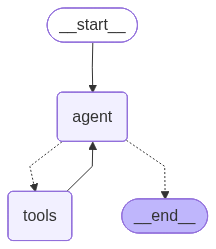

In [28]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [29]:
async def run_agent(agent, query):
    async for event in agent.astream(
        {"messages": [{"role": "user", "content": query}]},
        stream_mode="values",
    ):
        event["messages"][-1].pretty_print()

#### 5. Test

In [33]:
await run_agent(agent, "Use requests to read the CSV file from https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv and pandas to show me the first 5 rows.")

================================ Human Message =================================

Use requests to read the CSV file from https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv and pandas to show me the first 5 rows.
================================== Ai Message ==================================
Tool Calls:
  run_python_code (toolu_bdrk_01WcWSBMjzVR5uZfsUauC6Fz)
 Call ID: toolu_bdrk_01WcWSBMjzVR5uZfsUauC6Fz
  Args:
    python_code: import requests
import pandas as pd
import io

# URL of the CSV file
url = "https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv"

# Fetch the content of the CSV file
response = requests.get(url)
content = response.content

# Read the CSV content into a pandas DataFrame
df = pd.read_csv(io.StringIO(content.decode('utf-8')))

# Display the first 5 rows
print(df.head())
================================= Tool Message =================================
Name: run_python_code

<status>success</status>
<output>
  Month   "1958"   "1959"   "1960"
0   JAN 